In [27]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Total detectors 786, we are having 725 in triplets and 25 duets
df_triplets = pd.read_csv('./result_csv/triplets.csv')
df_duets = pd.read_csv('./result_csv/duets.csv')

dfv = pd.read_csv("./data/flow_10.23-03.24.csv")
dfl = pd.read_csv("./data/lane_10.23-03.24.csv")
dfv.loc[:,'timestamp'] = pd.to_datetime(dfv['timestamp'], errors='coerce')
dfv.set_index("timestamp",inplace=True)

In [5]:
# dfv.loc['2023-10-01 00:00:00':pd.Timestamp('2023-10-01 00:00:00') + pd.DateOffset(days=1),'AID01101_total_flow']

In [6]:
all_timestamps = list(pd.date_range(start='2023-10-01 00:00:00', end='2024-03-31 23:58:00', freq='1d'))
all_timestamps

[Timestamp('2023-10-01 00:00:00'),
 Timestamp('2023-10-02 00:00:00'),
 Timestamp('2023-10-03 00:00:00'),
 Timestamp('2023-10-04 00:00:00'),
 Timestamp('2023-10-05 00:00:00'),
 Timestamp('2023-10-06 00:00:00'),
 Timestamp('2023-10-07 00:00:00'),
 Timestamp('2023-10-08 00:00:00'),
 Timestamp('2023-10-09 00:00:00'),
 Timestamp('2023-10-10 00:00:00'),
 Timestamp('2023-10-11 00:00:00'),
 Timestamp('2023-10-12 00:00:00'),
 Timestamp('2023-10-13 00:00:00'),
 Timestamp('2023-10-14 00:00:00'),
 Timestamp('2023-10-15 00:00:00'),
 Timestamp('2023-10-16 00:00:00'),
 Timestamp('2023-10-17 00:00:00'),
 Timestamp('2023-10-18 00:00:00'),
 Timestamp('2023-10-19 00:00:00'),
 Timestamp('2023-10-20 00:00:00'),
 Timestamp('2023-10-21 00:00:00'),
 Timestamp('2023-10-22 00:00:00'),
 Timestamp('2023-10-23 00:00:00'),
 Timestamp('2023-10-24 00:00:00'),
 Timestamp('2023-10-25 00:00:00'),
 Timestamp('2023-10-26 00:00:00'),
 Timestamp('2023-10-27 00:00:00'),
 Timestamp('2023-10-28 00:00:00'),
 Timestamp('2023-10-

In [7]:
def calculate_correlation(df, detector1, detector2, start_date, end_date):
    # Filter the DataFrame for the given period
    filtered_df = df[start_date:end_date]
    
    # Calculate the correlation
    correlation = filtered_df[detector1].corr(filtered_df[detector2])
    return correlation

In [8]:
print(df_triplets.to_string())

                  0               1               2
0          AID01101        AID01102        AID01103
1          AID01102        AID01103        AID01104
2          AID01103        AID01104        AID01105
3          AID01104        AID01105        AID01106
4          AID01105        AID01106        AID01107
5          AID01108        AID01109        AID01110
6          AID01111        AID01112        AID01113
7          AID01112        AID01113        AID01114
8          AID01113        AID01114        AID01115
9          AID01114        AID01115        AID01116
10         AID01115        AID01116        AID01117
11         AID01116        AID01117        AID01118
12         AID01117        AID01118        AID01119
13         AID01118        AID01119        AID01120
14         AID01119        AID01120        AID01121
15         AID01120        AID01121        AID01122
16         AID01121        AID01122        AID01123
17         AID01124        AID01125        AID01126
18         A

In [9]:
triplets = list(df_triplets['0'])
triplets.extend(df_triplets['1'])
triplets.extend(df_triplets['2'])
triplets = list(set(triplets))
triplets = sorted(triplets)
print(len(triplets))

725


In [12]:
dfl = pd.read_csv("Z:/Hong Kong PolyU/Project/HKdata-fromTD/10.23-03.24/combined/lane_10.23-03.24.csv")
all_detectors = list(dfl['detector'])
dfl = dfl[dfl['speed_lane_count']!=0]
detectors = list(dfl['detector'])

In [13]:
len(detectors)

768

In [15]:
# count = 0
# for i in triplets:
#     if i in detectors:
#         count = count +1
# count

In [16]:
df = pd.DataFrame(np.nan, index=all_timestamps, columns=triplets)
df

,AID01101,AID01102,AID01103,AID01104,AID01105,AID01106,AID01107,AID01108,AID01109,AID01110,...,TDSTTR10003,TDSTYR10001,TDSTYR10002,TDSTYR10003,TDSYSR10001,TDSYSR10002,TDSYSR10003,TDSYSR20001,TDSYSR20002,TDSYSR20003
2023-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# # main loop
# # Rule for forming data matrix where 1 represents >0.9 correlation, -1 represents <0.9 correlation
# # And nan values are those days where >5% of data is null 

# for idx in df.index:

#     for i in df_triplets.index:
#         det = list(df_triplets.loc[i])
#         corr12 = corr23 = corr13 = 0
#         null1 = null2 = null3 = True
        
#         is1 = det[0]+'_total_flow' in dfv.columns 
#         is2 = det[1]+'_total_flow' in dfv.columns
#         is3 = det[2]+'_total_flow' in dfv.columns

#         if(is1 and is2 and is3):
        
#             det1 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[0]+'_total_flow']
#             det2 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[1]+'_total_flow']
#             det3 = dfv.loc[idx: idx + pd.DateOffset(days=1),det[2]+'_total_flow']
#             if(det1.isna().sum()<= 36): null1 = False
#             if(det2.isna().sum()<= 36): null2 = False
#             if(det3.isna().sum()<= 36): null3 = False

#             if(null1+null2+null3 == 0):
#                 corr12 = det1.corr(det2) > 0.89
#                 corr23 = det2.corr(det3) > 0.89
#                 corr13 = det1.corr(det3) > 0.84

#                 if(corr12 and corr23):
#                     df.loc[idx,det[0]]=1
#                     df.loc[idx,det[1]]=1
#                     df.loc[idx,det[2]]=1

#                 elif(corr12 and not(corr23)):
#                     df.loc[idx,det[0]]=1
#                     df.loc[idx,det[1]]=1
#                     if(df.loc[idx,det[2]]!=1): df.loc[idx,det[2]]=-1

#                 elif(not(corr12) and corr23):
#                     if(df.loc[idx,det[0]]!=1): df.loc[idx,det[0]]=-1
#                     df.loc[idx,det[1]]=1
#                     df.loc[idx,det[2]]=1

#                 elif(not(corr12) and not(corr23)):
#                     if(corr13):
#                         df.loc[idx,det[0]]=1
#                         if(df.loc[idx,det[1]]!=1): df.loc[idx,det[1]]=-1
#                         df.loc[idx,det[2]]=1
#                     else:
#                         if(df.loc[idx,det[0]]!=1): df.loc[idx,det[0]]=-1
#                         if(df.loc[idx,det[1]]!=1): df.loc[idx,det[1]]=-1
#                         if(df.loc[idx,det[2]]!=1): df.loc[idx,det[2]]=-1

                
#             elif(null1 and (not null2) and (not null3)):
#                 if(det2.corr(det3) > 0.89):
#                     df.loc[idx,det[1]]=1
#                     df.loc[idx,det[2]]=1
#                 else:
#                     if(df.loc[idx,det[1]]!=1): df.loc[idx,det[1]]=-1
#                     if(df.loc[idx,det[2]]!=1): df.loc[idx,det[2]]=-1

#             elif(null2 and (not null1) and (not null3)):
#                 if(det1.corr(det3) > 0.84):
#                     df.loc[idx,det[0]]=1
#                     df.loc[idx,det[2]]=1
#                 else:
#                     if(df.loc[idx,det[0]]!=1): df.loc[idx,det[0]]=-1
#                     if(df.loc[idx,det[2]]!=1): df.loc[idx,det[2]]=-1

#             elif(null3 and (not null1) and (not null2)):
#                 if(det1.corr(det2) > 0.89):
#                     df.loc[idx,det[0]]=1
#                     df.loc[idx,det[1]]=1
#                 else:
#                     if(df.loc[idx,det[0]]!=1): df.loc[idx,det[0]]=-1
#                     if(df.loc[idx,det[1]]!=1): df.loc[idx,det[1]]=-1

#             elif(null1+null2+null3 > 1):
#                 continue    

        

In [26]:
# df.to_csv('data_matrix.csv')
df = pd.read_csv('data_matrix.csv')
df

,timestamp,AID01101,AID01102,AID01103,AID01104,AID01105,AID01106,AID01107,AID01108,AID01109,...,TDSTTR10003,TDSTYR10001,TDSTYR10002,TDSTYR10003,TDSYSR10001,TDSYSR10002,TDSYSR10003,TDSYSR20001,TDSYSR20002,TDSYSR20003
0,2023-10-01,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,2023-10-02,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,2023-10-03,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0
3,2023-10-04,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0
4,2023-10-05,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,2024-03-27,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
179,2024-03-28,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
180,2024-03-29,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
181,2024-03-30,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [19]:
df = df.dropna(how = 'all', axis=1)
df.index.name = 'timestamp'
print(df.dropna(how = 'all',axis=1).to_string())

            timestamp  AID01101  AID01102  AID01103  AID01104  AID01105  AID01106  AID01107  AID01108  AID01109  AID01110  AID01111  AID01112  AID01113  AID01114  AID01115  AID01116  AID01117  AID01118  AID01119  AID01120  AID01121  AID01122  AID01123  AID01124  AID01125  AID01126  AID01127  AID01128  AID01129  AID01130  AID01131  AID01132  AID01133  AID01134  AID01135  AID01136  AID01201  AID01202  AID01203  AID01204  AID01205  AID01206  AID01207  AID01208  AID01209  AID01210  AID01211  AID01212  AID01213  AID01214  AID01215  AID01216  AID01217  AID01218  AID01219  AID01220  AID01221  AID01222  AID01223  AID02104  AID02105  AID02106  AID02107  AID02108  AID02109  AID02110  AID02111  AID02112  AID02113  AID02114  AID02115  AID02116  AID02117  AID02118  AID02119  AID02120  AID02121  AID02122  AID02123  AID02124  AID02125  AID02126  AID02127  AID02201  AID02202  AID02203  AID02204  AID02205  AID02206  AID02207  AID02208  AID02209  AID02210  AID02211  AID02212  AID02213  AID02214  AID0221

In [23]:
# Find the detectors for which we have less than 75 data points out of total 181 days
count_of_ones = df.eq(1).sum()
count_of_ones = count_of_ones.sort_values()
to_remove = count_of_ones[count_of_ones < 75].index.tolist()
print(count_of_ones)

timestamp           0
TDSCPRPS10003       0
TDSCPRPS10002       0
TDSCPRHSK20003      0
TDSCPRHSK20002      0
                 ... 
TDS90037          181
TDS91047          181
TDS91049          181
TDS90030          181
TDS91051          181
Length: 702, dtype: int64


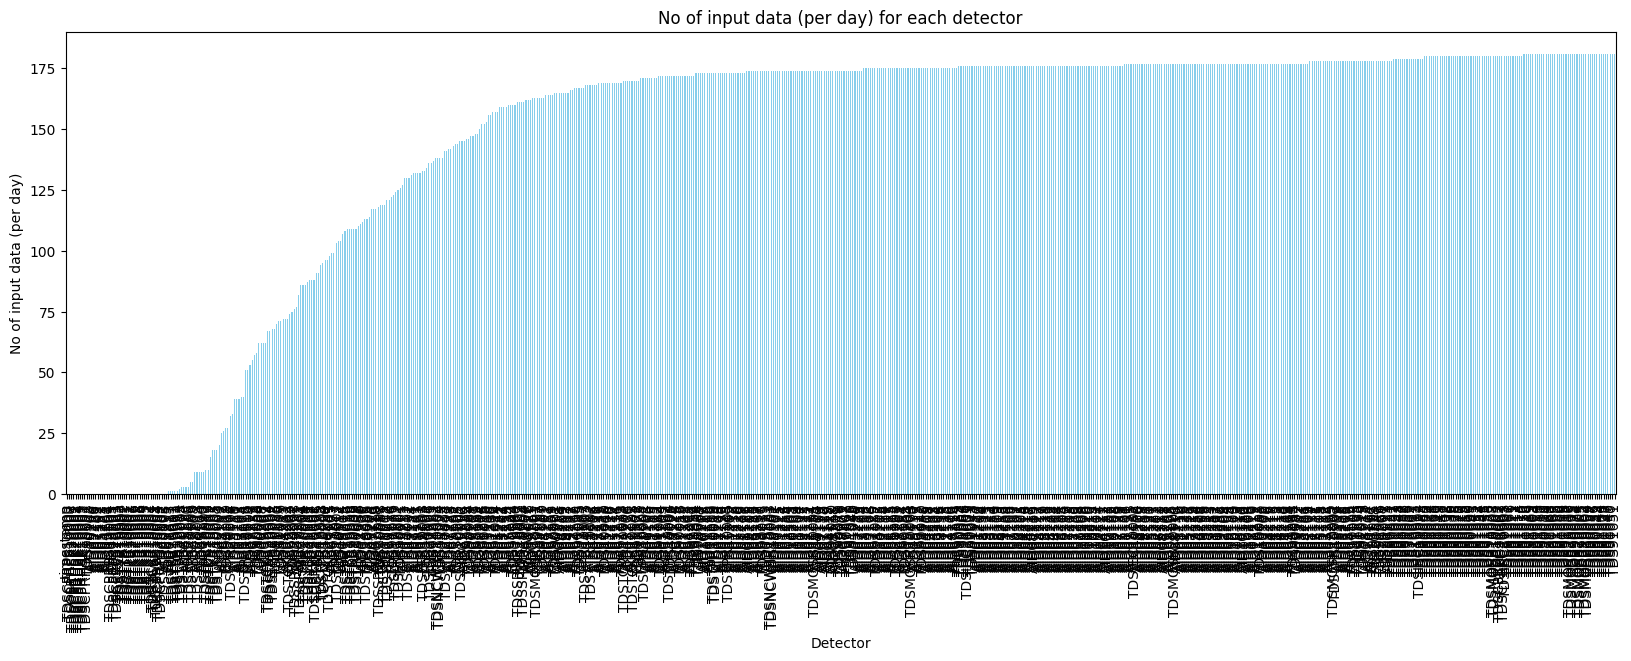

In [24]:
plt.figure(figsize=(20, 6))
count_of_ones.plot(kind='bar', color='skyblue')
plt.xlabel('Detector')
plt.ylabel('No of input data (per day)')
plt.title('No of input data (per day) for each detector')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# to_remove_df = pd.DataFrame(to_remove, columns=['to_remove'])
# to_remove_df.to_csv('to_remove.csv', index=False)